In [1]:
import sys
import tensorflow as tf

print(f"TensorFlow ver is {tf.__version__}")
print(f"PYTHON ver is {sys.version}")
print("GPU is","available" if tf.config.list_physical_devices('GPU') else "NOT AVAILABLE")

TensorFlow ver is 2.10.0
PYTHON ver is 3.9.13 (tags/v3.9.13:6de2ca5, May 17 2022, 16:36:42) [MSC v.1929 64 bit (AMD64)]
GPU is available


In [2]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
#tf.compat.v1.disable_eager_execution()

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import pandas as pd
from tensorflow import keras
#from tensorflow.keras import laters
import PIL
import PIL.Image
#import tensorflow_datasets as tfds
from PIL import Image
import cv2
%matplotlib inline
import pathlib
import sys
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.layers import Input, Dense, BatchNormalization, ReLU, Add, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.model_selection import train_test_split
import joblib

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
#tf.debugging.set_log_device_placement(True)     #계산시 어떤 장치로 계산하는지 표시하라는 명령어



In [3]:
# =========================
# 1) User settings
# =========================
DATA_DIR = "database"
DATA_FILE = "cmall_remove_duplicate_m_all.csv"   # <-- 정규화 전 CSV 파일명으로 수정하세요
QUALITY_MODEL_PATH = "best_model.h5"             # <-- 이미 학습된 품질예측 모델(입력 38개)
TARGET_BLAINE_DEFAULT = 3800.0                   # 학습용 고정 목표값(원하면 샘플링으로 확장 가능)

# If your CSV already has blaine_target column, set this to True.
USE_EXISTING_TARGET_COL = True

In [4]:
# =========================
# 2) Column definitions
# =========================
# (A) controllable (9): policy recommends delta for these
CONTROL_COLS_9 = [
    "RP_roller_p1",
    "RP_roller_p2",
    "RP_sep_rpm",
    "RP_sep_fan_damper",
    "RP_sep_BF_damper",
    "mill_BF_damper",
    "mill_sep_rpm",
    "mill_sep_fan_damper",
    "grind_aid",
]
assert len(CONTROL_COLS_9) == 9

# (B) monitoring (28): 기존 23 + feed 4 + Feed_total
MONITOR_COLS_28 = [
    # existing monitoring (23)
    "RP_spac",
    "RP_skew",
    "RP_roller_energy1",
    "RP_roller_energy2",
    "RP_roller_vib",
    "RP_BE_energy1",
    "RP_BE_energy2",
    "RP_sep_BF_pressure",
    "dosing_BE_energy",
    "mill_feed_c",
    "mill_feed_cir",
    "mill_energy",
    "mill_in_temp",
    "mill_out_temp",
    "mill_BE_energy",
    "mill_out_gas_temp",
    "mill_out_mater_temp",
    "mill_BF_pressure",
    "mill_sep_BF_pressure",
    "mill_sep_BF_fan_damper",
    "final_BE_1",
    "final_BE_2",
    "final_mater_temp",
    # feed composition moved to monitoring (4)
    "feed_clinker",
    "feed_gypsum",
    "feed_slag",
    "feed_FA",
    # total feed moved to monitoring (1)
    "feed_total",
]
assert len(MONITOR_COLS_28) == 28

PREV_QUALITY_COL = "blaine"
TARGET_QUALITY_COL = "blaine_target"  # policy input + training target (scaled)
#PREDICTED_QUALITY_NAME = "blaine"      # just for checking existence (optional)

# Quality model input order (MUST match the order used when training QUALITY_MODEL)
QUALITY_INPUT_COLS = CONTROL_COLS_9 + MONITOR_COLS_28 + [PREV_QUALITY_COL]
assert len(QUALITY_INPUT_COLS) == 38

# Policy input: monitor 28 + prev 1 + current control 9 + target 1 = 39
POLICY_INPUT_DIM = 28 + 1 + 9 + 1
assert POLICY_INPUT_DIM == 39

In [5]:
# =========================
# 3) Load raw data
# =========================
csv_path = os.path.join(DATA_DIR, DATA_FILE)
df = pd.read_csv(csv_path)

# Create/ensure target column
if USE_EXISTING_TARGET_COL:
    if TARGET_QUALITY_COL not in df.columns:
        raise ValueError(f"CSV must contain '{TARGET_QUALITY_COL}' when USE_EXISTING_TARGET_COL=True.")
else:
    df[TARGET_QUALITY_COL] = TARGET_BLAINE_DEFAULT

# Check required columns
required_cols = list(set(QUALITY_INPUT_COLS + [TARGET_QUALITY_COL]))
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns in CSV: {missing_cols}")

# Drop NA
df = df.dropna(subset=required_cols).reset_index(drop=True)

print(f"Loaded raw data: {df.shape} from {csv_path}")

Loaded raw data: (60632, 43) from database\cmall_remove_duplicate_m_all.csv


In [6]:
# =========================
# 4) Train/Val/Test split indices (IMPORTANT: scaler fit on TRAIN only)
# =========================
idx_all = np.arange(len(df))
idx_train, idx_temp = train_test_split(idx_all, test_size=0.30, random_state=42)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.50, random_state=42)

print(f"Split: train={len(idx_train)}, val={len(idx_val)}, test={len(idx_test)}")

Split: train=42442, val=9095, test=9095


In [7]:
# =========================
# 5) MinMax normalization (0~1) inside code
# =========================
# X scaler: fit on 38 quality input columns
scaler_x = MinMaxScaler(feature_range=(0.0, 1.0))
scaler_x.fit(df.loc[idx_all, QUALITY_INPUT_COLS].to_numpy(dtype=np.float32))

# y scaler: fit on blaine_target (so policy uses scaled target; and we compare in same scale as quality model output)
# NOTE:
# - This assumes your quality_model output was trained on a scaled blaine (0~1).
# - If your quality_model outputs raw blaine, set USE_Y_SCALER=False (and adjust loss accordingly).
USE_Y_SCALER = True
if USE_Y_SCALER:
    scaler_y_quality = MinMaxScaler(feature_range=(0.0, 1.0))
    scaler_y_quality.fit(df.loc[idx_all, [PREV_QUALITY_COL]].to_numpy(dtype=np.float32))
else:
    scaler_y = None

# Save scalers for inference reproducibility
joblib.dump(scaler_x, "scaler_x_38.pkl")
if scaler_y_quality is not None:
    joblib.dump(scaler_y_quality, "scaler_y_1.pkl")

print("MinMax scalers fitted (train only) and saved.")

MinMax scalers fitted (train only) and saved.


In [8]:
# =========================
# 6) Load pretrained quality model (FROZEN)
# =========================
quality_model = tf.keras.models.load_model('best_model_blaine.h5')
quality_model.trainable = False

# Quick sanity check: quality_model input shape expected (None,38)
try:
    print("Quality model input shape:", quality_model.input_shape)
    print("Quality model output shape:", quality_model.output_shape)
except Exception:
    pass

Quality model input shape: (None, 38)
Quality model output shape: (None, 1)


In [9]:
# =========================
# 7) Build normalized arrays for policy training
# =========================
# Raw arrays
u_cur_raw = df[CONTROL_COLS_9].to_numpy(dtype=np.float32)            # (N,9)
mon_raw   = df[MONITOR_COLS_28].to_numpy(dtype=np.float32)           # (N,28)
prev_raw  = df[[PREV_QUALITY_COL]].to_numpy(dtype=np.float32)        # (N,1)
yT_raw    = df[[TARGET_QUALITY_COL]].to_numpy(dtype=np.float32)      # (N,1)

# Quality-model input raw (38)
Xq_raw = np.concatenate([u_cur_raw, mon_raw, prev_raw], axis=1)      # (N,38)

# Normalize Xq to 0~1
Xq_norm = scaler_x.transform(Xq_raw).astype(np.float32)              # (N,38)

# Split normalized components
u_cur_norm = Xq_norm[:, :9]
mon_norm   = Xq_norm[:, 9:9+28]
prev_norm  = Xq_norm[:, 9+28:9+28+1]

# Normalize target y
if scaler_y_quality is not None:
    yT_norm = scaler_y_quality.transform(yT_raw).astype(np.float32)          # (N,1)
else:
    yT_norm = yT_raw.astype(np.float32)

# Policy input (39): [mon(28), prev(1), u_cur(9), yT(1)]
Xp = np.concatenate([mon_norm, prev_norm, u_cur_norm, yT_norm], axis=1).astype(np.float32)

# Split using indices
Xp_train, yT_train = Xp[idx_train], yT_norm[idx_train]
Xp_val,   yT_val   = Xp[idx_val],   yT_norm[idx_val]
Xp_test,  yT_test  = Xp[idx_test],  yT_norm[idx_test]

# tf.data
BATCH_SIZE = 1024
train_ds = tf.data.Dataset.from_tensor_slices((Xp_train, yT_train)).shuffle(20000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds   = tf.data.Dataset.from_tensor_slices((Xp_val, yT_val)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds  = tf.data.Dataset.from_tensor_slices((Xp_test, yT_test)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Policy dataset ready:",
      "train", Xp_train.shape, yT_train.shape,
      "| val", Xp_val.shape, yT_val.shape,
      "| test", Xp_test.shape, yT_test.shape)

Policy dataset ready: train (42442, 39) (42442, 1) | val (9095, 39) (9095, 1) | test (9095, 39) (9095, 1)


In [10]:
# =========================
# 8) Build policy network (delta-u for 9 controls)
# - Input  : 39 (monitor 28 + prev 1 + control 9 + target 1)
# - Output : delta_u for 9 controllable variables (tanh, [-1, 1])
# =========================
def build_policy_model(input_shape):
    model = Sequential([
        Dense(256, activation='swish',
              kernel_initializer='glorot_uniform',
              input_shape=input_shape),
        BatchNormalization(),
        Dropout(0.1),

        Dense(256, activation='swish',
              kernel_initializer='glorot_uniform'),
        BatchNormalization(),
        Dropout(0.1),

        Dense(128, activation='swish',
              kernel_initializer='glorot_uniform'),
        BatchNormalization(),

        # Δu 출력 (정규화 공간, [-1, 1])
        Dense(9, activation='tanh', name='delta_raw')
    ])
    return model


# ============================================================
# Policy model 생성
# ============================================================
policy_input_shape = (39,)
policy_net = build_policy_model(policy_input_shape)

policy_net.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               10240     
                                                                 
 batch_normalization (BatchN  (None, 256)              1024      
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 256)               65792     
                                                                 
 batch_normalization_1 (Batc  (None, 256)              1024      
 hNormalization)                                                 
                                                                 
 dropout_1 (Dropout)         (None, 256)               0

In [11]:
# ============================================================
# 9) Delta bounds (per-control) in normalized space
# ============================================================
import numpy as np
import tensorflow as tf

# 초기값(임시): 운영 경험에 맞게 변수별로 반드시 튜닝 권장
# 예: damper는 0.05, rpm은 0.02, grind_aid는 0.01 등
DELTA_MAX = np.array([0.02] * 9, dtype=np.float32)  # shape (9,)
DELTA_MAX_TF = tf.constant(DELTA_MAX.reshape(1, -1), dtype=tf.float32)

In [12]:
# ============================================================
# 10) Wrapper model: frozen quality model + trainable policy model
# ============================================================
class ControlRecommender(tf.keras.Model):
    def __init__(self, policy_net: tf.keras.Model, quality_model: tf.keras.Model,
                 lam_l2: float = 1.0, lam_l1: float = 0.1, huber_delta: float = 1.0):
        super().__init__()
        self.policy_net = policy_net
        self.quality_model = quality_model  # frozen

        self.lam_l2 = lam_l2
        self.lam_l1 = lam_l1
        self.huber_delta = huber_delta

        self.loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.pred_loss_tracker = tf.keras.metrics.Mean(name="pred_loss")
        self.delta_l2_tracker = tf.keras.metrics.Mean(name="delta_l2")
        self.delta_l1_tracker = tf.keras.metrics.Mean(name="delta_l1")

    @property
    def metrics(self):
        return [self.loss_tracker, self.pred_loss_tracker, self.delta_l2_tracker, self.delta_l1_tracker]

    def call(self, Xp_batch, training=False):
        """
        Xp layout (39):
          [mon(28), prev(1), u_cur(9), y_target(1)]
        """
        mon  = Xp_batch[:, 0:28]
        prev = Xp_batch[:, 28:29]
        u_cur = Xp_batch[:, 29:38]
        # y_target = Xp_batch[:, 38:39]  # policy input에 포함(여기서 따로 쓰진 않음)

        # Sequential policy_net: outputs delta_raw (B,9) in [-1,1]
        delta_raw = self.policy_net(Xp_batch, training=training)
        delta = delta_raw * DELTA_MAX_TF

        # u_new in normalized space
        u_new = tf.clip_by_value(u_cur + delta, 0.0, 1.0)

        # quality input (38): [u_new(9), mon(28), prev(1)]
        Xq_new = tf.concat([u_new, mon, prev], axis=1)

        # frozen quality prediction
        y_pred = self.quality_model(Xq_new, training=False)

        return u_new, y_pred, delta

    def train_step(self, data):
        Xp_batch, y_target_batch = data

        with tf.GradientTape() as tape:
            u_new, y_pred, delta = self(Xp_batch, training=True)

            pred_loss = tf.reduce_mean(
                tf.keras.losses.huber(y_target_batch, y_pred, delta=self.huber_delta)
            )

            delta_l2 = tf.reduce_mean(tf.reduce_sum(tf.square(delta), axis=1))
            delta_l1 = tf.reduce_mean(tf.reduce_sum(tf.abs(delta), axis=1))

            loss = pred_loss + self.lam_l2 * delta_l2 + self.lam_l1 * delta_l1

        grads = tape.gradient(loss, self.policy_net.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.policy_net.trainable_variables))

        self.loss_tracker.update_state(loss)
        self.pred_loss_tracker.update_state(pred_loss)
        self.delta_l2_tracker.update_state(delta_l2)
        self.delta_l1_tracker.update_state(delta_l1)

        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        Xp_batch, y_target_batch = data

        u_new, y_pred, delta = self(Xp_batch, training=False)

        pred_loss = tf.reduce_mean(
            tf.keras.losses.huber(y_target_batch, y_pred, delta=self.huber_delta)
        )
        delta_l2 = tf.reduce_mean(tf.reduce_sum(tf.square(delta), axis=1))
        delta_l1 = tf.reduce_mean(tf.reduce_sum(tf.abs(delta), axis=1))

        loss = pred_loss + self.lam_l2 * delta_l2 + self.lam_l1 * delta_l1

        self.loss_tracker.update_state(loss)
        self.pred_loss_tracker.update_state(pred_loss)
        self.delta_l2_tracker.update_state(delta_l2)
        self.delta_l1_tracker.update_state(delta_l1)

        return {m.name: m.result() for m in self.metrics}

In [13]:
# ============================================================
# 11) Train policy (recommender)  - FIXED (no HDF5 for subclassed model)
# ============================================================
quality_model.trainable = False

recommender = ControlRecommender(
    policy_net=policy_net,
    quality_model=quality_model,
    lam_l2=1.0,
    lam_l1=0.1,
    huber_delta=1.0
)
recommender.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4))

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=50, restore_best_weights=True
)

history = recommender.fit(
    train_ds,
    validation_data=val_ds,
    epochs=500,
    callbacks=[early_stop]
)

print("\nEvaluation on test set:")
recommender.evaluate(test_ds)

# ---- 학습 완료 후, policy_net만 저장 (권장)
policy_net.save("best_policy_net.keras")   # Keras v3 포맷 (추천)
# 또는 SavedModel 포맷:
# policy_net.save("best_policy_net_savedmodel", save_format="tf")
print("Saved policy_net to: best_policy_net.keras")


Epoch 1/500
42/42 [==============================] - 4s 33ms/step - loss: 0.0477 - pred_loss: 0.0391 - delta_l2: 9.5458e-04 - delta_l1: 0.0762 - val_loss: 0.0422 - val_pred_loss: 0.0403 - val_delta_l2: 5.6113e-05 - val_delta_l1: 0.0184
Epoch 2/500
42/42 [==============================] - 1s 19ms/step - loss: 0.0437 - pred_loss: 0.0390 - delta_l2: 3.9042e-04 - delta_l1: 0.0434 - val_loss: 0.0422 - val_pred_loss: 0.0401 - val_delta_l2: 8.2926e-05 - val_delta_l1: 0.0199
Epoch 3/500
42/42 [==============================] - 1s 19ms/step - loss: 0.0427 - pred_loss: 0.0391 - delta_l2: 2.7027e-04 - delta_l1: 0.0333 - val_loss: 0.0420 - val_pred_loss: 0.0402 - val_delta_l2: 6.8744e-05 - val_delta_l1: 0.0170
Epoch 4/500
42/42 [==============================] - 1s 19ms/step - loss: 0.0422 - pred_loss: 0.0393 - delta_l2: 1.9760e-04 - delta_l1: 0.0267 - val_loss: 0.0418 - val_pred_loss: 0.0403 - val_delta_l2: 5.8770e-05 - val_delta_l1: 0.0148
Epoch 5/500
42/42 [==============================] - 1s 

In [14]:
# ------------------------------------------------
# Load trained policy network
# ------------------------------------------------
policy_net_loaded = tf.keras.models.load_model("best_policy_net.keras")

# recommender 재구성 (quality_model은 기존 것 그대로)
quality_model.trainable = False
recommender_loaded = ControlRecommender(
    policy_net=policy_net_loaded,
    quality_model=quality_model,
    lam_l2=1.0,
    lam_l1=0.1,
    huber_delta=1.0
)

recommender_loaded.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4)
)

In [15]:
# ------------------------------------------------
# Evaluate policy recommender on test set
# ------------------------------------------------
test_metrics = recommender_loaded.evaluate(test_ds, return_dict=True)

print("Policy evaluation on test set:")
for k, v in test_metrics.items():
    print(f"{k:15s}: {v:.6f}")

9/9 [==============================] - 1s 6ms/step - loss: 0.0402 - pred_loss: 0.0390 - delta_l2: 1.6703e-04 - delta_l1: 0.0110
Policy evaluation on test set:
loss           : 0.040235
pred_loss      : 0.038972
delta_l2       : 0.000167
delta_l1       : 0.010955


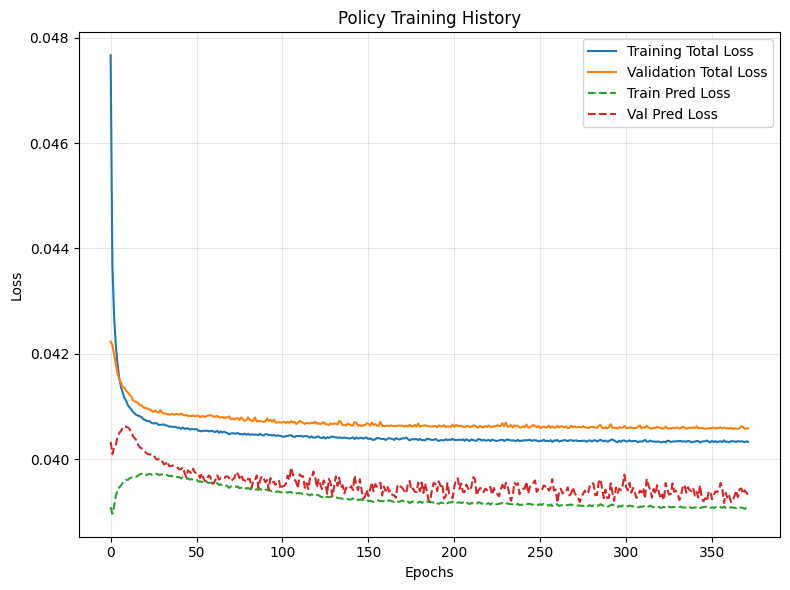

In [16]:
# ------------------------------------------------
# Plot training history
# ------------------------------------------------
plt.figure(figsize=(8, 6))

plt.plot(history.history["loss"], label="Training Total Loss")
plt.plot(history.history["val_loss"], label="Validation Total Loss")

plt.plot(history.history["pred_loss"], "--", label="Train Pred Loss")
plt.plot(history.history["val_pred_loss"], "--", label="Val Pred Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Policy Training History")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# 학습 완료 후 모델 검증

In [17]:
# ------------------------------------------------
# Policy effect check on test samples
# (normalized + real scale)
# ------------------------------------------------
def evaluate_policy_effect_with_real_scale(
    recommender, dataset, scaler_y, n_skip_batches=1, n_batches=1
):
    err_before_norm = []
    err_after_norm  = []

    err_before_real = []
    err_after_real  = []

    for Xp_batch, y_target_norm in dataset.skip(n_skip_batches).take(n_batches):

        # AFTER policy
        u_new, y_pred_new_norm, _ = recommender(Xp_batch, training=False)

        # BEFORE policy
        mon  = Xp_batch[:, 0:28]
        prev = Xp_batch[:, 28:29]
        u_cur = Xp_batch[:, 29:38]

        Xq_cur = tf.concat([u_cur, mon, prev], axis=1)
        y_pred_cur_norm = quality_model(Xq_cur, training=False)

        # -------------------------
        # Normalized errors (0~1)
        # -------------------------
        err_b_norm = tf.abs(y_pred_cur_norm - y_target_norm)
        err_a_norm = tf.abs(y_pred_new_norm - y_target_norm)

        err_before_norm.append(err_b_norm.numpy())
        err_after_norm.append(err_a_norm.numpy())

        # -------------------------
        # Real-scale (Blaine) errors
        # -------------------------
        y_target_real   = scaler_y_quality.inverse_transform(y_target_norm.numpy())
        y_pred_cur_real = scaler_y_quality.inverse_transform(y_pred_cur_norm.numpy())
        y_pred_new_real = scaler_y_quality.inverse_transform(y_pred_new_norm.numpy())

        err_b_real = np.abs(y_pred_cur_real - y_target_real)
        err_a_real = np.abs(y_pred_new_real - y_target_real)

        err_before_real.append(err_b_real)
        err_after_real.append(err_a_real)

    return (
        np.mean(err_before_norm),
        np.mean(err_after_norm),
        np.mean(err_before_real),
        np.mean(err_after_real),
    )

err_b_n, err_a_n, err_b_r, err_a_r = evaluate_policy_effect_with_real_scale(
    recommender_loaded,
    test_ds,
    scaler_y_quality,
    n_skip_batches=3,   # 앞쪽 batch는 스킵
    n_batches=4   # 디버그용, 필요 시 늘리기
)

print("=== Policy Effect Evaluation ===")
print(f"[Normalized]")
print(f"  Mean |error| BEFORE policy : {err_b_n:.6f}")
print(f"  Mean |error| AFTER  policy : {err_a_n:.6f}")
print(f"  Improvement ratio          : {(1 - err_a_n/err_b_n)*100:.2f}%")

print()
print(f"[Real Blaine scale]")
print(f"  Mean |error| BEFORE policy : {err_b_r:.2f} Blaine")
print(f"  Mean |error| AFTER  policy : {err_a_r:.2f} Blaine")
print(f"  Improvement                : {(err_b_r - err_a_r):.2f} Blaine")



=== Policy Effect Evaluation ===
[Normalized]
  Mean |error| BEFORE policy : 0.274963
  Mean |error| AFTER  policy : 0.267708
  Improvement ratio          : 2.64%

[Real Blaine scale]
  Mean |error| BEFORE policy : 366.53 Blaine
  Mean |error| AFTER  policy : 356.85 Blaine
  Improvement                : 9.67 Blaine


In [18]:

# ============================================================
# 12) Inference: real-time recommendation (one-shot)
#     - Raw row -> normalize -> policy -> inverse to raw controls
# ============================================================
def recommend_controls_one_row(df_row, target_blaine_raw: float,
                              scaler_x, scaler_y,
                              recommender):
    u_raw = df_row[CONTROL_COLS_9].to_numpy(dtype=np.float32).reshape(1, -1)
    mon_raw = df_row[MONITOR_COLS_28].to_numpy(dtype=np.float32).reshape(1, -1)
    prev_raw = np.array([[df_row[PREV_QUALITY_COL]]], dtype=np.float32)

    Xq_raw = np.concatenate([u_raw, mon_raw, prev_raw], axis=1).astype(np.float32)
    Xq_norm = scaler_x.transform(Xq_raw).astype(np.float32)

    u_norm   = Xq_norm[:, :9]
    mon_norm = Xq_norm[:, 9:9+28]
    prev_norm= Xq_norm[:, 9+28:9+28+1]

    yT_raw = np.array([[target_blaine_raw]], dtype=np.float32)
    yT_norm = scaler_y.transform(yT_raw).astype(np.float32) if scaler_y is not None else yT_raw.astype(np.float32)

    Xp_norm = np.concatenate([mon_norm, prev_norm, u_norm, yT_norm], axis=1).astype(np.float32)

    u_new_norm, y_pred_norm, delta_norm = recommender(tf.constant(Xp_norm), training=False)

    # inverse controls
    Xq_new_norm = np.concatenate([u_new_norm.numpy(), mon_norm, prev_norm], axis=1)
    Xq_new_raw  = scaler_x.inverse_transform(Xq_new_norm)
    rec_controls_raw = Xq_new_raw[:, :9].flatten()

    # inverse current controls (for delta_raw)
    Xq_cur_norm = np.concatenate([u_norm, mon_norm, prev_norm], axis=1)
    Xq_cur_raw  = scaler_x.inverse_transform(Xq_cur_norm)
    u_cur_raw_back = Xq_cur_raw[:, :9].flatten()
    delta_raw = rec_controls_raw - u_cur_raw_back

    # inverse predicted blaine
    pred_blaine_raw = scaler_y_quality.inverse_transform(y_pred_norm.numpy()).flatten()[0] if scaler_y is not None else float(y_pred_norm.numpy().flatten()[0])

    return (
        dict(zip(CONTROL_COLS_9, rec_controls_raw)),
        pred_blaine_raw,
        delta_norm.numpy().flatten(),
        dict(zip(CONTROL_COLS_9, delta_raw))
    )

In [19]:
import numpy as np
import pandas as pd

# ------------------------------------------------
# Example usage: one-shot control recommendation (detailed view)
# ------------------------------------------------
row_idx = 28
row = df.iloc[row_idx]

TARGET_BLAINE = 3800.0

# (1) 정책 추천 실행
rec_controls, pred_blaine, delta_norm, delta_raw = recommend_controls_one_row(
    df_row=row,
    target_blaine_raw=TARGET_BLAINE,
    scaler_x=scaler_x,
    scaler_y=scaler_y_quality,
    recommender=recommender_loaded
)

# (2) 현재(기존) 제어값 raw 추출
cur_controls = row[CONTROL_COLS_9].to_dict()   # {control_name: value}

# (3) BEFORE 품질 예측 (현재 제어 그대로)
u_cur_raw = row[CONTROL_COLS_9].to_numpy(dtype=np.float32).reshape(1, -1)
mon_raw   = row[MONITOR_COLS_28].to_numpy(dtype=np.float32).reshape(1, -1)
prev_raw  = np.array([[row[PREV_QUALITY_COL]]], dtype=np.float32)

Xq_cur_raw  = np.concatenate([u_cur_raw, mon_raw, prev_raw], axis=1).astype(np.float32)
Xq_cur_norm = scaler_x.transform(Xq_cur_raw).astype(np.float32)

y_before_norm = quality_model(Xq_cur_norm, training=False).numpy()
y_before_raw  = scaler_y_quality.inverse_transform(y_before_norm)[0, 0]

# ------------------------------------------------
# (4) 출력: 제어변수 비교 테이블
# ------------------------------------------------
rows = []
for c in CONTROL_COLS_9:
    cur_v = float(cur_controls[c])
    rec_v = float(rec_controls[c])
    d_raw = float(delta_raw[c]) if isinstance(delta_raw, dict) else (rec_v - cur_v)
    rows.append([c, cur_v, rec_v, d_raw])

df_controls_cmp = pd.DataFrame(
    rows, columns=["control", "current_raw", "recommended_raw", "delta_raw"]
)

# 보기 좋게 정렬/표시(선택)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("====================================")
print(f"Row index        : {row_idx}")
print(f"Target Blaine    : {TARGET_BLAINE:,.1f}")
print("------------------------------------")
print(f"Pred Blaine BEFORE (current controls): {y_before_raw:,.1f}")
print(f"Pred Blaine AFTER  (recommended)     : {pred_blaine:,.1f}")
print(f"Improvement (AFTER - BEFORE)        : {pred_blaine - y_before_raw:+,.1f}")
print("====================================")
print(df_controls_cmp.to_string(index=False))
print("====================================")


Row index        : 28
Target Blaine    : 3,800.0
------------------------------------
Pred Blaine BEFORE (current controls): 3,412.1
Pred Blaine AFTER  (recommended)     : 3,423.9
Improvement (AFTER - BEFORE)        : +11.8
            control  current_raw  recommended_raw  delta_raw
       RP_roller_p1      77.0000          77.0048     0.0048
       RP_roller_p2      82.0000          82.0013     0.0013
         RP_sep_rpm     400.0000         399.9870    -0.0130
  RP_sep_fan_damper     100.0000         100.0000    -0.0000
   RP_sep_BF_damper      60.0000          59.9994    -0.0006
     mill_BF_damper      15.0000          14.9994    -0.0006
       mill_sep_rpm   1,139.0000       1,143.3832     4.3832
mill_sep_fan_damper     100.0000         100.0000     0.0000
          grind_aid     151.2000         121.3772   -29.8228
